In [37]:
import pandas as pd

df = pd.read_csv('state_data.csv')

print(df)

#df.shape[0]
print(df.shape[0])
#df.shape[1]
print(df.shape[1])

#first 5 rows:
df.head()
print(df.head())

#last 5 rows
df.tail()
print(df.tail())

print("the 'state' column represents the abbreviation for the different states")
print("the 'latitude' and 'longitute' columns represent their placement on a map")
print("the 'name' represents the actual names of the states")
print("the first state is Alaska and the last state is Wyoming")
print("there are 52 entries total, and the reason it isn't 50 is because it's accounting for the titling, and fact that it starts at 0")

median_lat = df['latitude'].median()
median_lon = df['longitude'].median()

df.eval("""
    lat_dist = abs(latitude - @median_lat)
    lon_dist = abs(longitude - @median_lon)
""", inplace=True)
# using the df.eval() helps when doing column-based math because it creates a clearer syntax

print(df.shape)

print(median_lat, median_lon)

df['lat_dist'] = (df['latitude'] - median_lat).abs()
df['lon_dist'] = (df['longitude'] - median_lon).abs()

df.shape

#closest/farthest latitude
closest_lat = df.loc[df['lat_dist'].idxmin()]
farthest_lat = df.loc[df['lat_dist'].idxmax()]

#closest/farthest longitude
closest_lon = df.loc[df['lon_dist'].idxmin()]
farthest_lon = df.loc[df['lon_dist'].idxmax()]

print(f"closest to median latitude: {closest_lat['name']} ({closest_lat['lat_dist']:.2f}")
print(f"farthest from median latitude: {farthest_lat['name']} ({farthest_lat['lat_dist']:.2f})")

print(f"closest to median longitude: {closest_lon['name']} ({closest_lon['lon_dist']:.2f})")
print(f"farthest from median longitude: {farthest_lon['name']} ({farthest_lon['lon_dist']:.2f})")




   state   latitude   longitude                  name
0     AK  63.588753 -154.493062                Alaska
1     AL  32.318231  -86.902298               Alabama
2     AR  35.201050  -91.831833              Arkansas
3     AZ  34.048928 -111.093731               Arizona
4     CA  36.778261 -119.417932            California
5     CO  39.550051 -105.782067              Colorado
6     CT  41.603221  -73.087749           Connecticut
7     DC  38.905985  -77.033418  District of Columbia
8     DE  38.910832  -75.527670              Delaware
9     FL  27.664827  -81.515754               Florida
10    GA  32.157435  -82.907123               Georgia
11    HI  19.898682 -155.665857                Hawaii
12    IA  41.878003  -93.097702                  Iowa
13    ID  44.068202 -114.742041                 Idaho
14    IL  40.633125  -89.398528              Illinois
15    IN  40.551217  -85.602364               Indiana
16    KS  39.011902  -98.484246                Kansas
17    KY  37.839333  -84.270

Shape: (20, 5)
Rows: 20, Columns: 5
First 5: 
    subidr    attnr  num1  num2  num3
0       1  divided     2   4.0     7
1       2  divided     3   4.0     5
2       3  divided     3   5.0     6
3       4  divided     5   7.0     5
4       5  divided     4   5.0     8
Last 5: 
     subidr    attnr  num1  num2  num3
15      16  focused     6   8.0     7
16      17  focused     7   7.0     6
17      18  focused     7   8.0     6
18      19  focused     5   6.0     6
19      20  focused     6   6.0     5
['subidr', 'attnr', 'num1', 'num2', 'num3']
subidr: subject ID for each participant 
attnr: attention condition (divided or focused) 
num1, num2, num3: the number of possible solutions to the anagrams, columns contain the memory performance scores


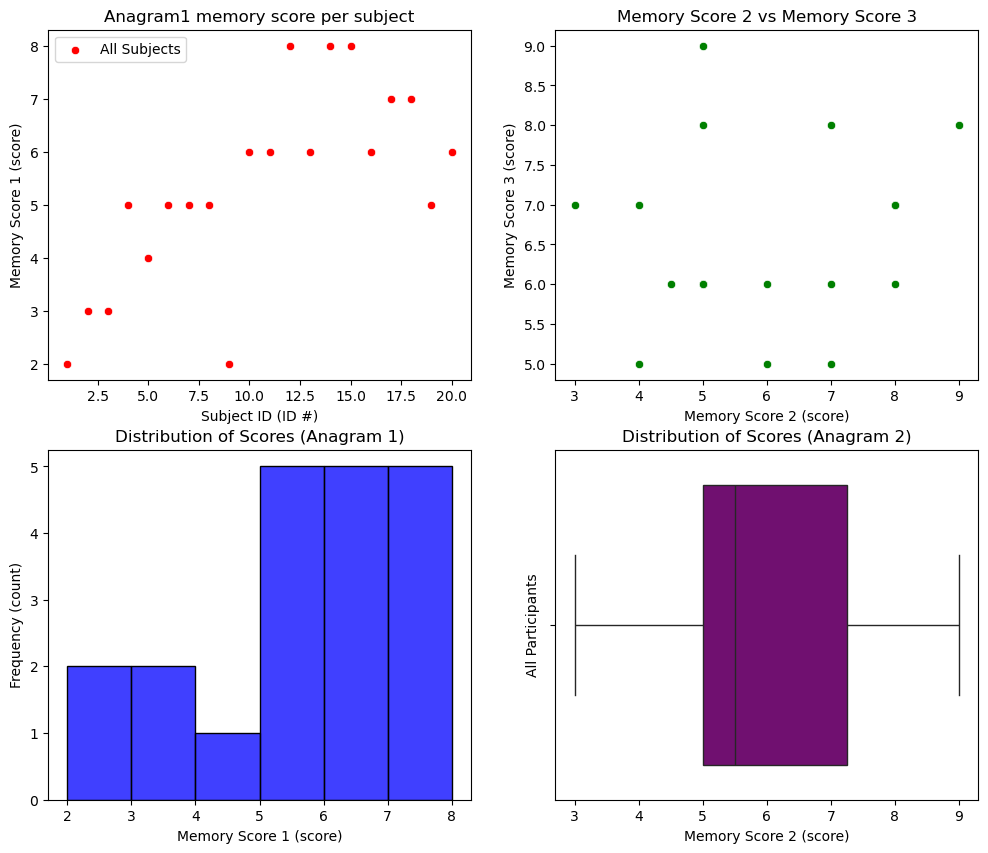

Top left subplot: The data represents the memory scores for an anagram with one solution by subject. I picked these columns to see if later participants would score better. I learned that later participants generally do score better. 
        
Top right subplot: The data represents the correlation between two memory scores. I picked these columns to see if a high score in one test predicted a high score in another test. I learned that there is no evident correlation between memory scores between tests.
        
Bottom left subplot: The data represents the distribution of memory scores for an anagram with one solution. I picked this column to see the distribution of how people scored for an anagram with one solution. I learned that most people scored on the higher end for an anagram with one solution, as the distribution is skewed left.
        
Bottom right subplot: The data represents the distribution of memory scores for an anagram with two solutions. I picked this column to see the 

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt #subplots doesn't work without matplotlib.pyplot

df = sns.load_dataset("anagrams")
df = df.dropna(axis = 1)
print(f"Shape: {df.shape}")
print(f"Rows: {len(df)}, Columns: {len(df.columns)}")
print(f"First 5: \n {df.head(5)}")
print(f"Last 5: \n {df.tail(5)}")
print(list(df.columns))
print(f"subidr: subject ID for each participant \nattnr: attention condition (divided or focused) \nnum1, num2, num3: the number of possible solutions to the anagrams, columns contain the memory performance scores")
fig, axes = plt.subplots(2, 2, figsize = (12, 10))
sns.scatterplot(data = df, x = "subidr", y = "num1", ax = axes[0, 0], color = "red", label = "All Subjects")
axes[0, 0].set_title("Anagram1 memory score per subject")
axes[0, 0].set_xlabel("Subject ID (ID #)")
axes[0, 0].set_ylabel("Memory Score 1 (score)")
axes[0, 0].legend()
sns.scatterplot(data = df, x = "num2", y = "num3", ax = axes[0, 1], color = "green")
axes[0, 1].set_title("Memory Score 2 vs Memory Score 3")
axes[0, 1].set_xlabel("Memory Score 2 (score)")
axes[0, 1].set_ylabel("Memory Score 3 (score)")
sns.histplot(data = df, x = "num1", ax = axes[1, 0], color = "blue")
axes[1, 0].set_title("Distribution of Scores (Anagram 1)")
axes[1, 0].set_xlabel("Memory Score 1 (score)")
axes[1, 0].set_ylabel("Frequency (count)")
sns.boxplot(data = df, x = "num2", ax = axes[1, 1], color = "purple")
axes[1, 1].set_title("Distribution of Scores (Anagram 2)")
axes[1, 1].set_xlabel("Memory Score 2 (score)")
axes[1, 1].set_ylabel("All Participants")
plt.show()
print("""Top left subplot: The data represents the memory scores for an anagram with one solution by subject. I picked these columns to see if later participants would score better. I learned that later participants generally do score better. 
        \nTop right subplot: The data represents the correlation between two memory scores. I picked these columns to see if a high score in one test predicted a high score in another test. I learned that there is no evident correlation between memory scores between tests.
        \nBottom left subplot: The data represents the distribution of memory scores for an anagram with one solution. I picked this column to see the distribution of how people scored for an anagram with one solution. I learned that most people scored on the higher end for an anagram with one solution, as the distribution is skewed left.
        \nBottom right subplot: The data represents the distribution of memory scores for an anagram with two solutions. I picked this column to see the distribution of how people scored for an anagram with two solutions. I learned that about the distribution is relatively even, but the median is around 5.5.""")